## Exploración Extra: Preprocesamiento avanzado de imágenes - Dataset Alternativo
## Práctica 13B - Dataset Alternativo
**Ingeniería de Datos — Universidad Católica del Uruguay**

## 🎯 Objetivo  
Aplicar el mismo pipeline de preprocesamiento de imágenes a un dataset alternativo, incluyendo:  
- Representación y diagnóstico inicial
- Espacios de color y realce de contraste
- Suavizado y detección de bordes
- Detección y descripción de *features* (ORB/SIFT)
- Métricas y dashboard de QA

---

**Dataset alternativo:** Imágenes de naturaleza, arquitectura y texturas (moon, text, chelsea, brick, grass, etc.)


In [1]:
!pip install -q opencv-python opencv-contrib-python numpy matplotlib scikit-image pandas --break-system-packages

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import exposure, filters, feature, color, img_as_float, data as skdata, io as skio
import skimage
import pathlib, warnings, platform, os
warnings.filterwarnings('ignore')

print("✅ Librerías listas")
print(f"OpenCV: {cv2.__version__}")
print(f"scikit-image: {skimage.__version__}")
print(f"Python: {platform.python_version()}")


zsh:1: command not found: pip
✅ Librerías listas
OpenCV: 4.12.0
scikit-image: 0.25.2
Python: 3.13.5


## 0) Dataset Alternativo - Carga de Imágenes

Usaremos un conjunto diferente de imágenes de scikit-image para demostrar la versatilidad del pipeline.


In [2]:
# Crear directorio para imágenes
RAW_DIR = pathlib.Path("data/raw_alt")
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Dataset alternativo: imágenes diferentes a las de la práctica original
samples_alt = {
    "moon.png": skdata.moon(),
    "text.png": skdata.text(),
    "chelsea.png": skdata.chelsea(),
    "brick.png": skdata.brick(),
    "grass.png": skdata.grass(),
    "hubble_deep_field.png": skdata.hubble_deep_field(),
}

# Guardar imágenes
for name, img in samples_alt.items():
    out = RAW_DIR / name
    skio.imsave(out.as_posix(), img)

print(f"✅ Dataset alternativo descargado: {len(samples_alt)} imágenes")
print("Imágenes:", list(samples_alt.keys()))


✅ Dataset alternativo descargado: 6 imágenes
Imágenes: ['moon.png', 'text.png', 'chelsea.png', 'brick.png', 'grass.png', 'hubble_deep_field.png']


## 1) Representación y Diagnóstico Inicial

Seleccionamos una imagen representativa del dataset alternativo para el análisis completo.


Dimensiones: H=512 W=512
Rango: 0-255
Media: 112.17, STD: 13.33


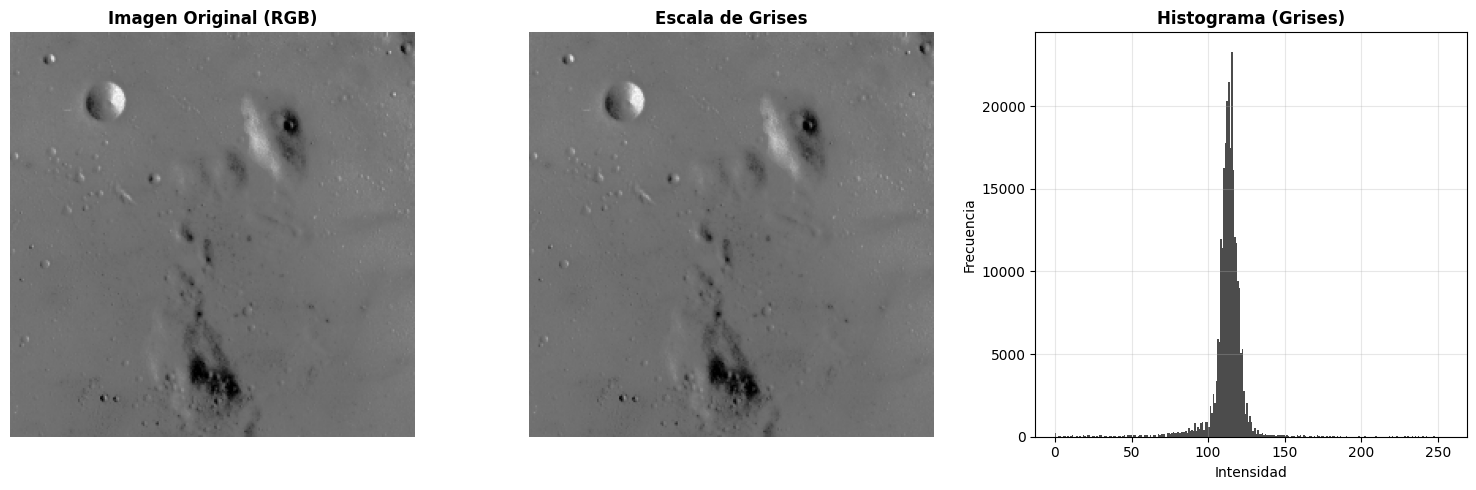

In [3]:
# Seleccionar imagen principal (moon para análisis completo)
img_path = RAW_DIR / "moon.png"
img_gray_sk = skio.imread(img_path.as_posix(), as_gray=True)

# Convertir a formato OpenCV (BGR)
img_bgr = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

height, width = img_gray.shape
min_val, max_val = img_gray.min(), img_gray.max()
mean_val = img_gray.mean()
std_val = img_gray.std()

print(f"Dimensiones: H={height} W={width}")
print(f"Rango: {min_val}-{max_val}")
print(f"Media: {mean_val:.2f}, STD: {std_val:.2f}")

# Visualización inicial
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Imagen Original (RGB)", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title("Escala de Grises", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].hist(img_gray.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
axes[2].set_title("Histograma (Grises)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Intensidad")
axes[2].set_ylabel("Frecuencia")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/ut5b_histograma_moon.png', dpi=150, bbox_inches='tight')
plt.show()


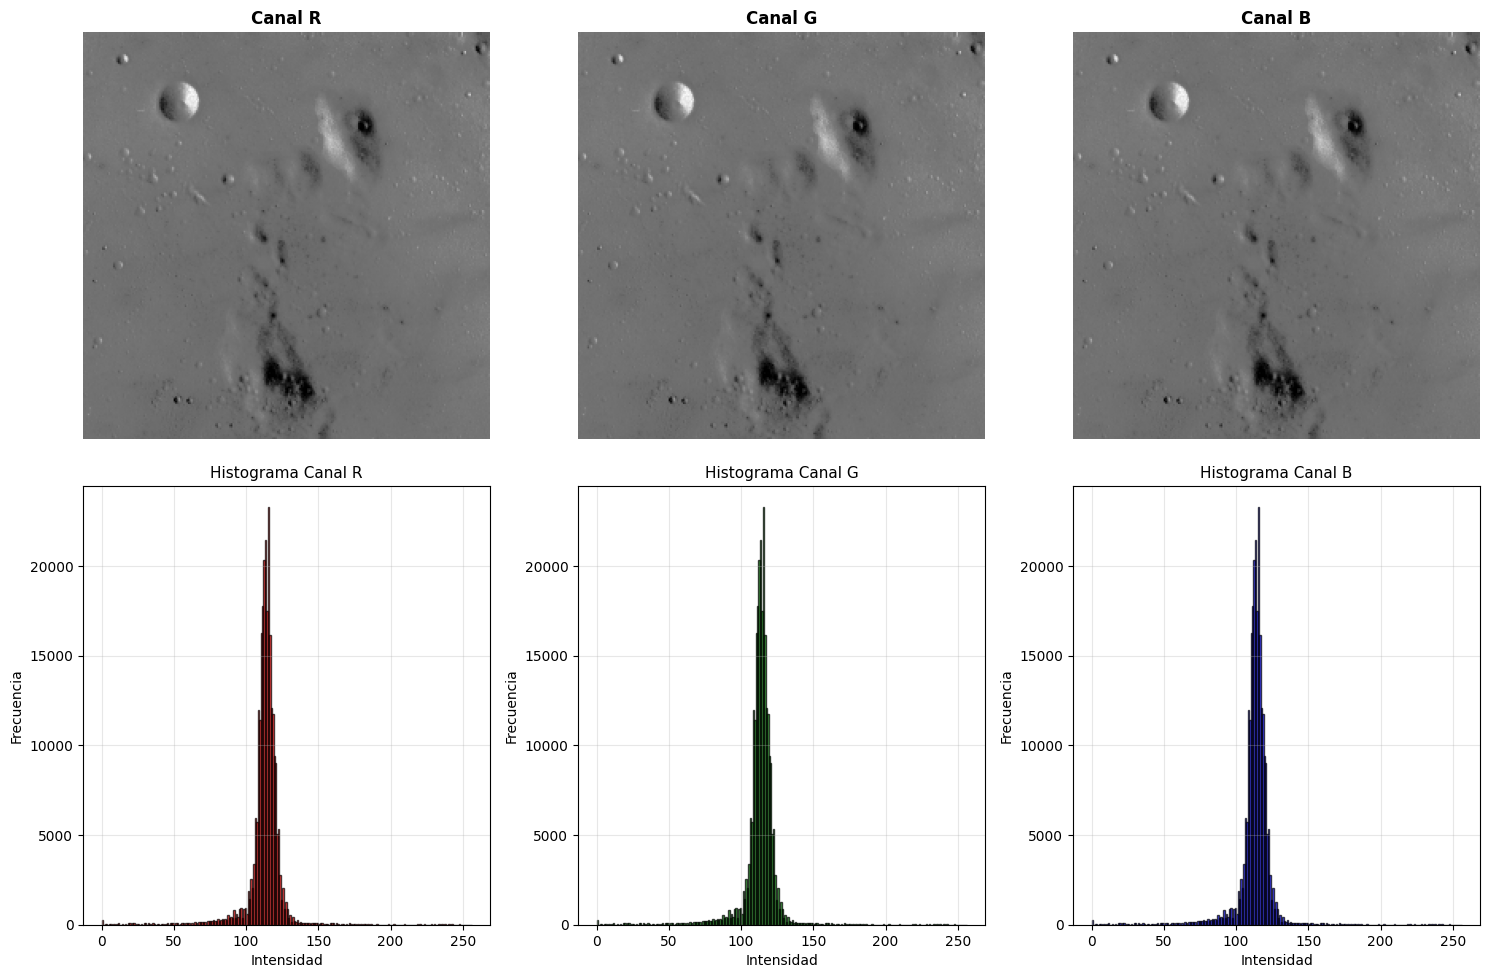

In [4]:
# Histogramas por canal RGB
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Mostrar canales individuales
for i, (channel, color_name) in enumerate(zip(cv2.split(img_rgb), ['R', 'G', 'B'])):
    axes[0, i].imshow(channel, cmap='gray')
    axes[0, i].set_title(f"Canal {color_name}", fontsize=12, fontweight='bold')
    axes[0, i].axis('off')
    
    axes[1, i].hist(channel.ravel(), bins=256, range=(0, 256), 
                    color=color_name.lower(), alpha=0.7, edgecolor='black')
    axes[1, i].set_title(f"Histograma Canal {color_name}", fontsize=11)
    axes[1, i].set_xlabel("Intensidad")
    axes[1, i].set_ylabel("Frecuencia")
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/ut5b_hist_rgb_moon.png', dpi=150, bbox_inches='tight')
plt.show()


## 2) Espacios de Color y Realce de Contraste

Aplicamos ecualización global y CLAHE para mejorar el contraste.


STD Contraste - Original: 13.33
STD Contraste - Equalize: 74.01
STD Contraste - CLAHE: 18.64


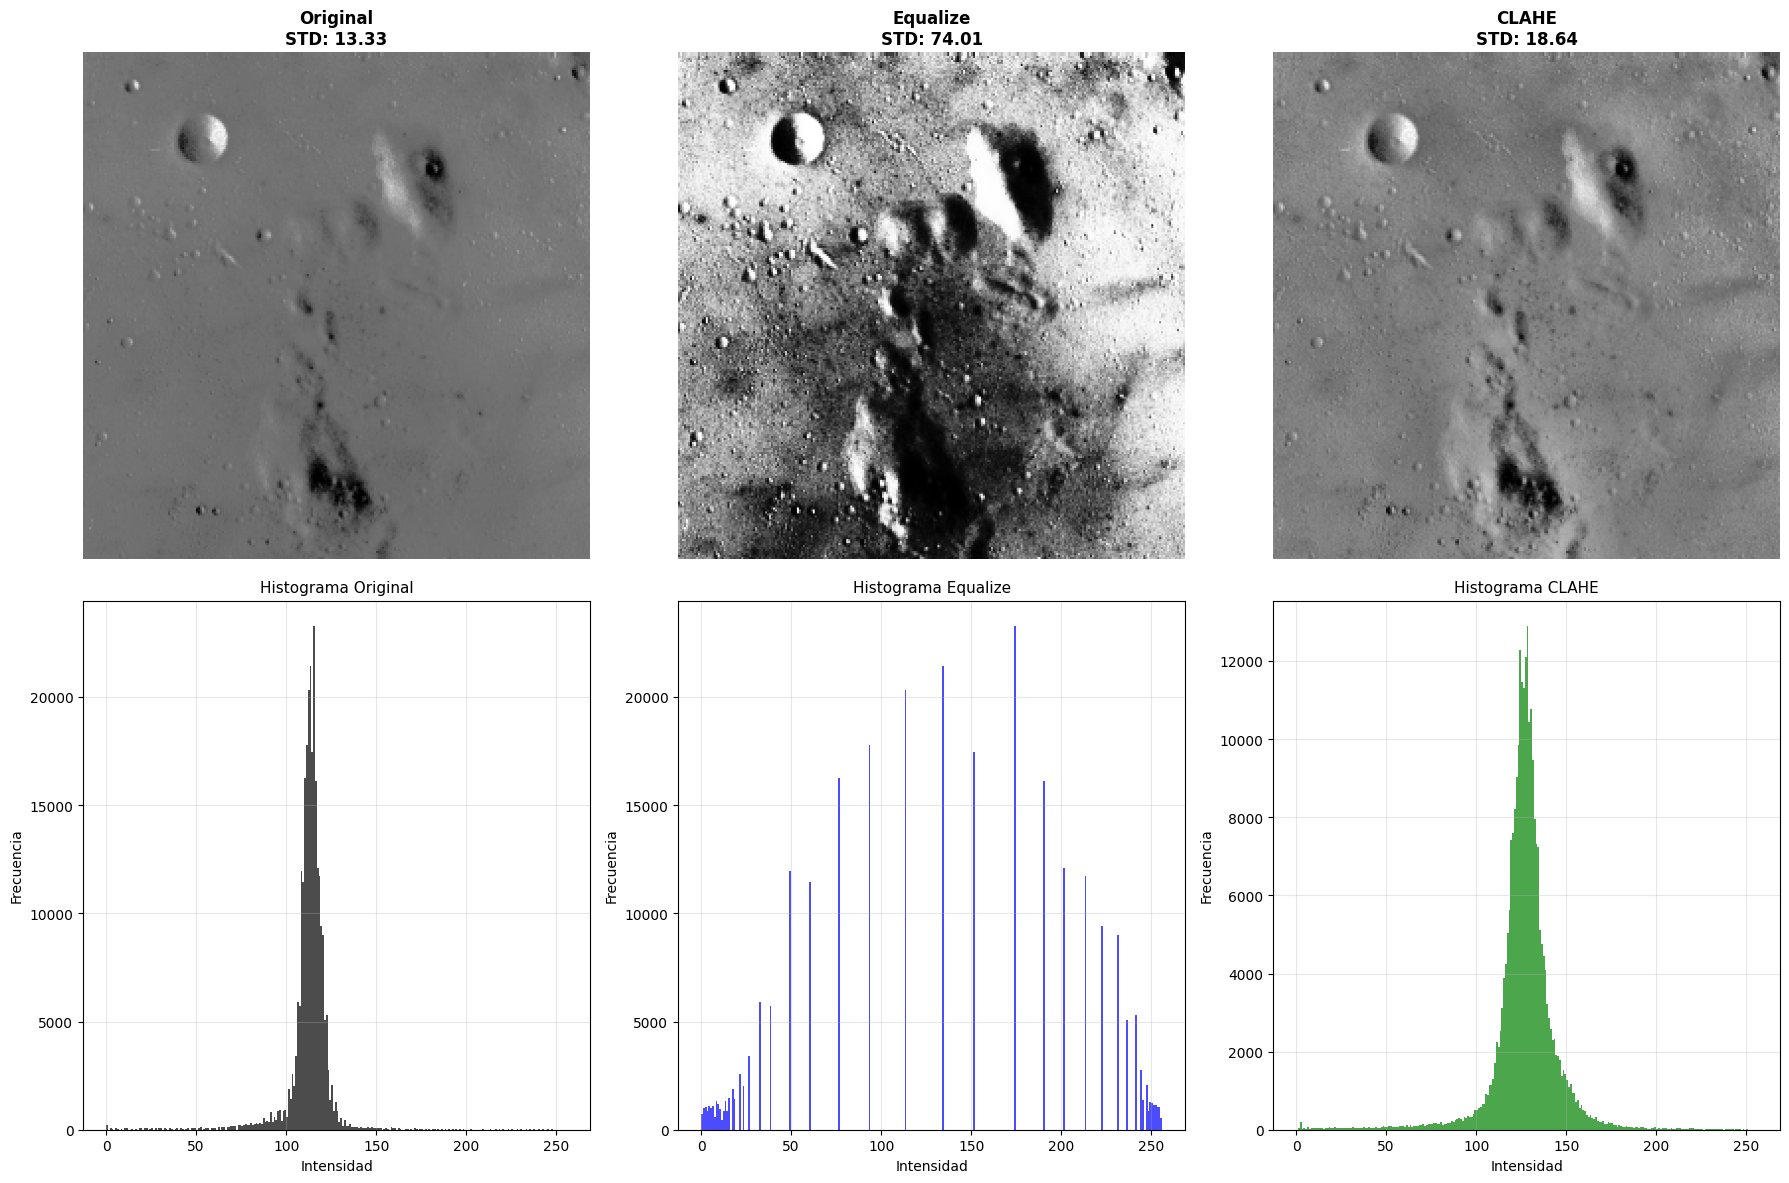

In [5]:
# Ecualización global en grises
img_eq = cv2.equalizeHist(img_gray)

# CLAHE en espacio LAB
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, A, B = cv2.split(img_lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
L_clahe = clahe.apply(L)
lab_clahe = cv2.merge([L_clahe, A, B])
rgb_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
# El canal L ya es la luminancia, así que lo usamos directamente
img_gray_clahe = L_clahe

# Calcular métricas de contraste
std_original = img_gray.std()
std_equalize = img_eq.std()
std_clahe = img_gray_clahe.std()

print(f"STD Contraste - Original: {std_original:.2f}")
print(f"STD Contraste - Equalize: {std_equalize:.2f}")
print(f"STD Contraste - CLAHE: {std_clahe:.2f}")

# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Fila 1: Imágenes
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title(f"Original\nSTD: {std_original:.2f}", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_eq, cmap='gray')
axes[0, 1].set_title(f"Equalize\nSTD: {std_equalize:.2f}", fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_gray_clahe, cmap='gray')
axes[0, 2].set_title(f"CLAHE\nSTD: {std_clahe:.2f}", fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Fila 2: Histogramas
axes[1, 0].hist(img_gray.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
axes[1, 0].set_title("Histograma Original", fontsize=11)
axes[1, 0].set_xlabel("Intensidad")
axes[1, 0].set_ylabel("Frecuencia")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(img_eq.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
axes[1, 1].set_title("Histograma Equalize", fontsize=11)
axes[1, 1].set_xlabel("Intensidad")
axes[1, 1].set_ylabel("Frecuencia")
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(img_gray_clahe.ravel(), bins=256, range=(0, 256), color='green', alpha=0.7)
axes[1, 2].set_title("Histograma CLAHE", fontsize=11)
axes[1, 2].set_xlabel("Intensidad")
axes[1, 2].set_ylabel("Frecuencia")
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/ut5b_contraste_comparacion_moon.png', dpi=150, bbox_inches='tight')
plt.show()


## 3) Suavizado y Detección de Bordes

Aplicamos filtros gaussiano y bilateral, seguidos de detección de bordes con Canny.


Varianza del gradiente - Original: 458
Varianza del gradiente - Gaussian: 240
Varianza del gradiente - Bilateral: 140

Ratio de bordes - Original: 0.004
Ratio de bordes - Gaussian: 0.002
Ratio de bordes - Bilateral: 0.001


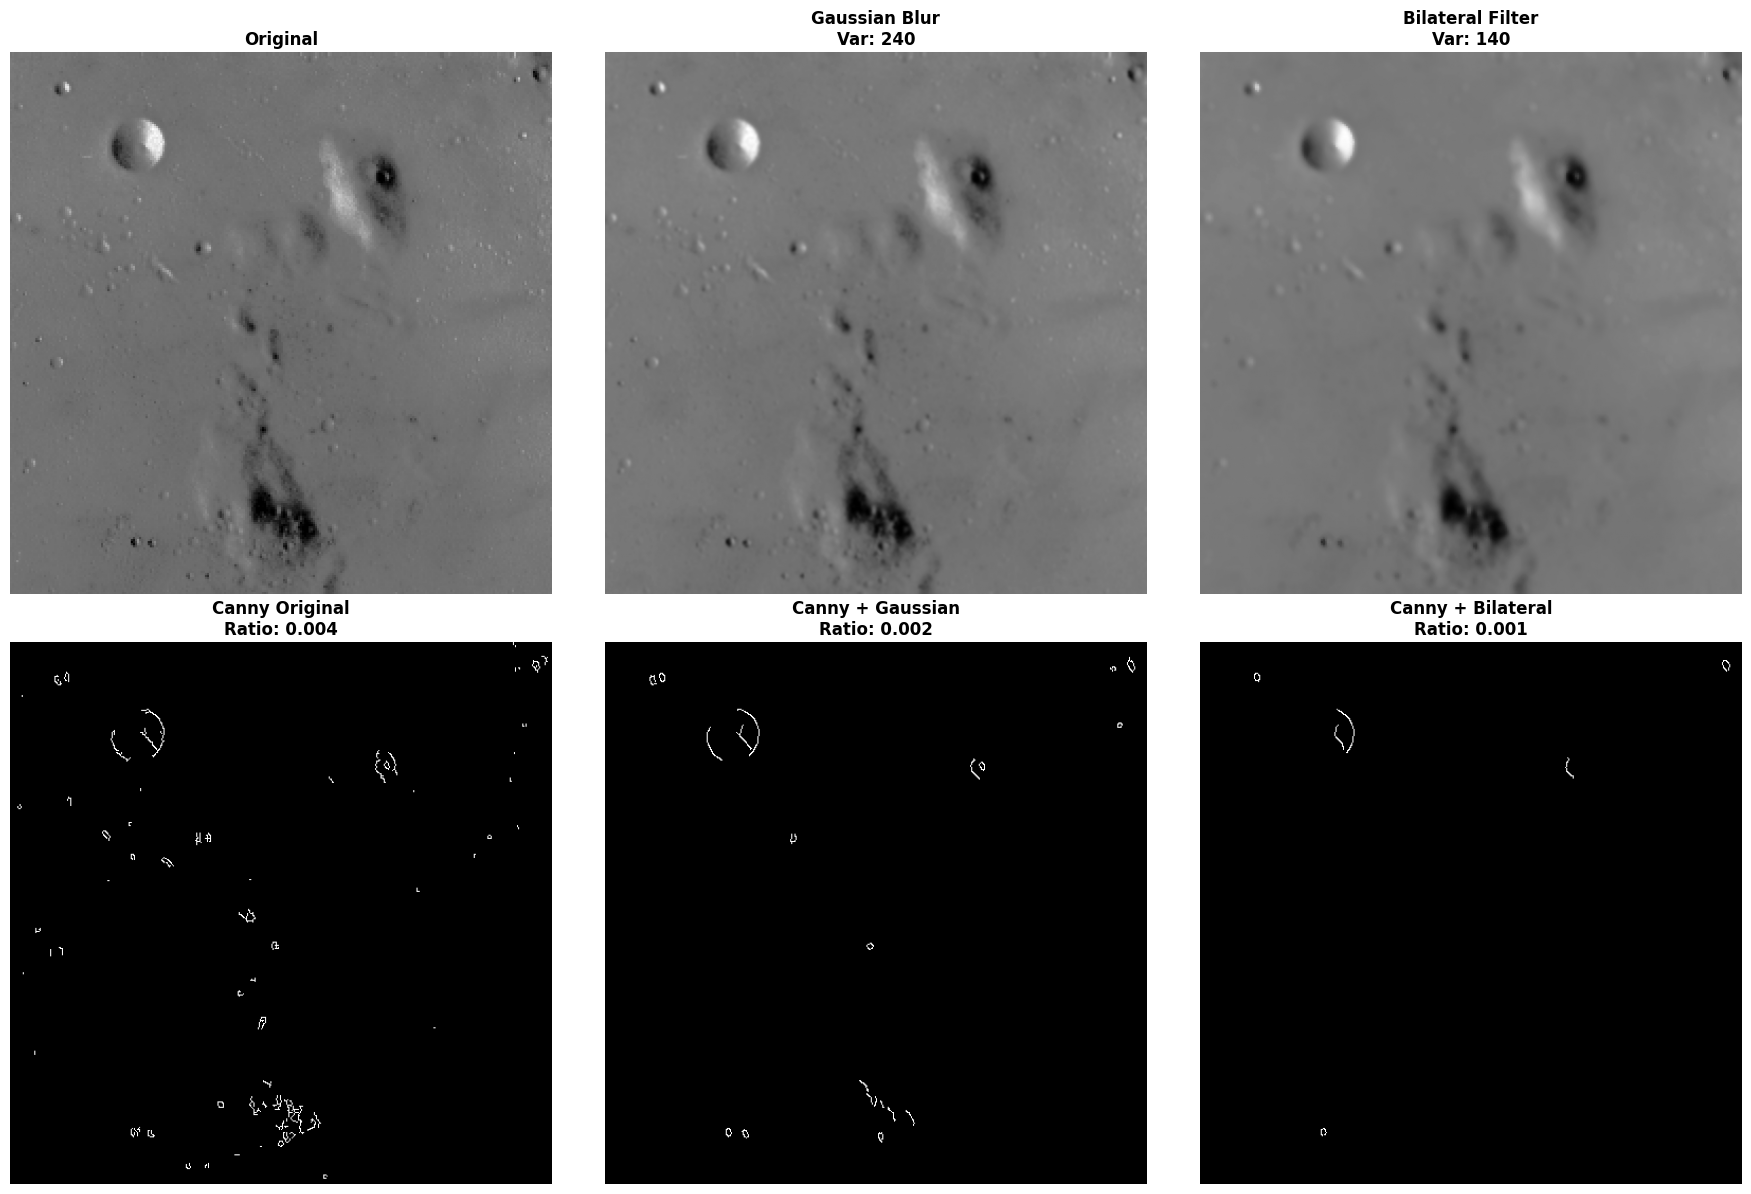

In [6]:
# Aplicar suavizado
gaussian = cv2.GaussianBlur(img_gray, (5, 5), 0)
bilateral = cv2.bilateralFilter(img_gray, d=9, sigmaColor=75, sigmaSpace=75)

# Detección de bordes con Canny
edges_original = cv2.Canny(img_gray, 100, 200)
edges_gaussian = cv2.Canny(gaussian, 100, 200)
edges_bilateral = cv2.Canny(bilateral, 100, 200)

# Calcular métricas
def gradient_variance(img):
    grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    gradient_mag = np.sqrt(grad_x**2 + grad_y**2)
    return gradient_mag.var()

def edge_ratio(edges):
    return (edges > 0).sum() / edges.size

var_orig = gradient_variance(img_gray)
var_gauss = gradient_variance(gaussian)
var_bilat = gradient_variance(bilateral)

ratio_orig = edge_ratio(edges_original)
ratio_gauss = edge_ratio(edges_gaussian)
ratio_bilat = edge_ratio(edges_bilateral)

print(f"Varianza del gradiente - Original: {var_orig:.0f}")
print(f"Varianza del gradiente - Gaussian: {var_gauss:.0f}")
print(f"Varianza del gradiente - Bilateral: {var_bilat:.0f}")
print(f"\nRatio de bordes - Original: {ratio_orig:.3f}")
print(f"Ratio de bordes - Gaussian: {ratio_gauss:.3f}")
print(f"Ratio de bordes - Bilateral: {ratio_bilat:.3f}")

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Fila 1: Imágenes suavizadas
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title("Original", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(gaussian, cmap='gray')
axes[0, 1].set_title(f"Gaussian Blur\nVar: {var_gauss:.0f}", fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(bilateral, cmap='gray')
axes[0, 2].set_title(f"Bilateral Filter\nVar: {var_bilat:.0f}", fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Fila 2: Bordes detectados
axes[1, 0].imshow(edges_original, cmap='gray')
axes[1, 0].set_title(f"Canny Original\nRatio: {ratio_orig:.3f}", fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(edges_gaussian, cmap='gray')
axes[1, 1].set_title(f"Canny + Gaussian\nRatio: {ratio_gauss:.3f}", fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(edges_bilateral, cmap='gray')
axes[1, 2].set_title(f"Canny + Bilateral\nRatio: {ratio_bilat:.3f}", fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('../assets/ut5b_suavizado_bordes_moon.png', dpi=150, bbox_inches='tight')
plt.show()


Keypoints detectados - Original: 645
Keypoints detectados - CLAHE: 939
Keypoints detectados - Bilateral: 121


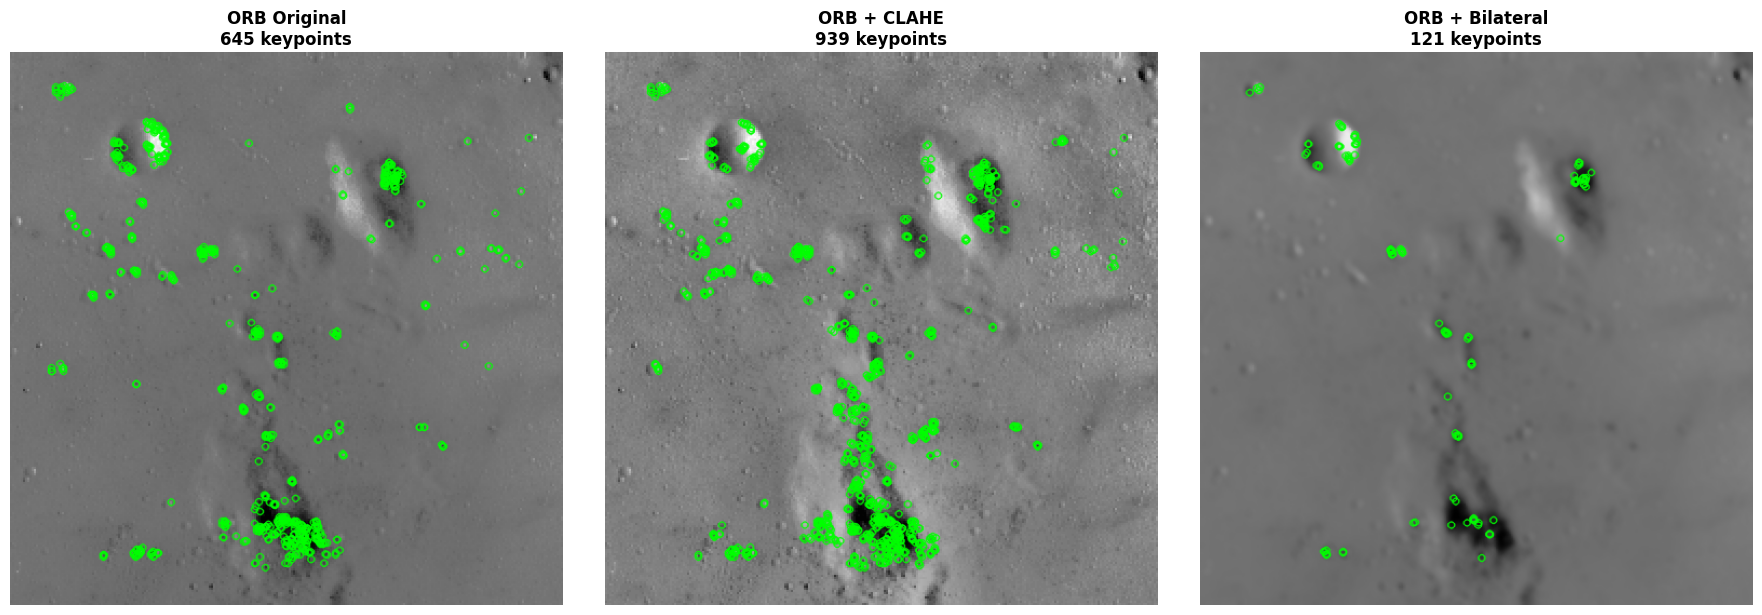

In [7]:
# Crear detector ORB
orb = cv2.ORB_create(nfeatures=1000)

# Detectar keypoints en diferentes versiones
def detect_and_draw_keypoints(img, title):
    kp, des = orb.detectAndCompute(img, None)
    img_kp = cv2.drawKeypoints(img, kp, None, color=(0, 255, 0), flags=0)
    return img_kp, len(kp), kp, des

img_kp_orig, n_kp_orig, kp_orig, des_orig = detect_and_draw_keypoints(img_gray, "Original")
img_kp_clahe, n_kp_clahe, kp_clahe, des_clahe = detect_and_draw_keypoints(img_gray_clahe, "CLAHE")
img_kp_bilat, n_kp_bilat, kp_bilat, des_bilat = detect_and_draw_keypoints(bilateral, "Bilateral")

print(f"Keypoints detectados - Original: {n_kp_orig}")
print(f"Keypoints detectados - CLAHE: {n_kp_clahe}")
print(f"Keypoints detectados - Bilateral: {n_kp_bilat}")

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_kp_orig, cmap='gray')
axes[0].set_title(f"ORB Original\n{n_kp_orig} keypoints", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_kp_clahe, cmap='gray')
axes[1].set_title(f"ORB + CLAHE\n{n_kp_clahe} keypoints", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_kp_bilat, cmap='gray')
axes[2].set_title(f"ORB + Bilateral\n{n_kp_bilat} keypoints", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../assets/ut5b_orb_keypoints_moon.png', dpi=150, bbox_inches='tight')
plt.show()


Matches encontrados: 337
Distancia promedio: 30.16


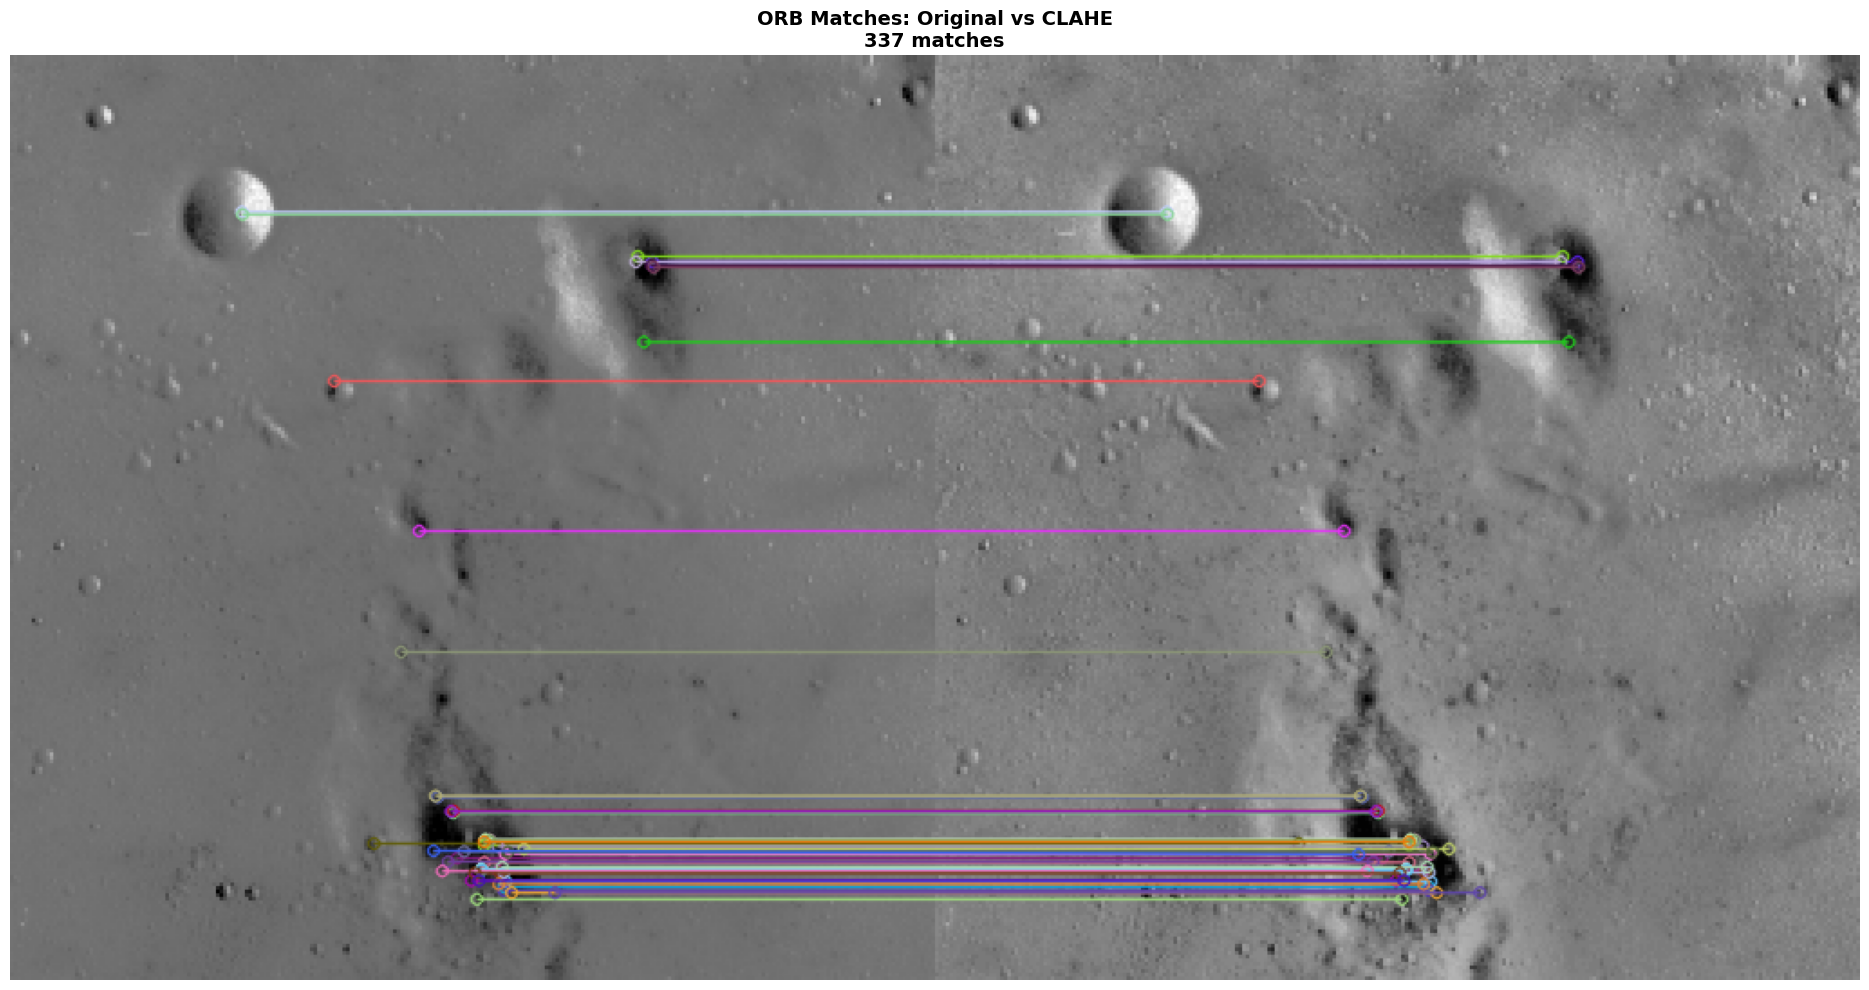

In [8]:
# Matching entre original y CLAHE
if des_orig is not None and des_clahe is not None:
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des_orig, des_clahe)
    matches = sorted(matches, key=lambda x: x.distance)
    
    # Dibujar matches
    img_matches = cv2.drawMatches(img_gray, kp_orig, img_gray_clahe, kp_clahe, 
                                  matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    print(f"Matches encontrados: {len(matches)}")
    print(f"Distancia promedio: {np.mean([m.distance for m in matches]):.2f}")
    
    plt.figure(figsize=(20, 10))
    plt.imshow(img_matches, cmap='gray')
    plt.title(f"ORB Matches: Original vs CLAHE\n{len(matches)} matches", 
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('../assets/ut5b_orb_matches_moon.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se pudieron calcular matches (descriptores insuficientes)")


## 5) Análisis de Sensibilidad y Benchmark

Evaluamos la sensibilidad de ORB a diferentes parámetros y comparamos con SIFT.


Sensibilidad de ORB a parámetros CLAHE:
tile_size   16x16  4x4  8x8
clip_limit                 
1.0           881  836  860
2.0           958  926  939
3.0           987  976  982
4.0          1000  996  998


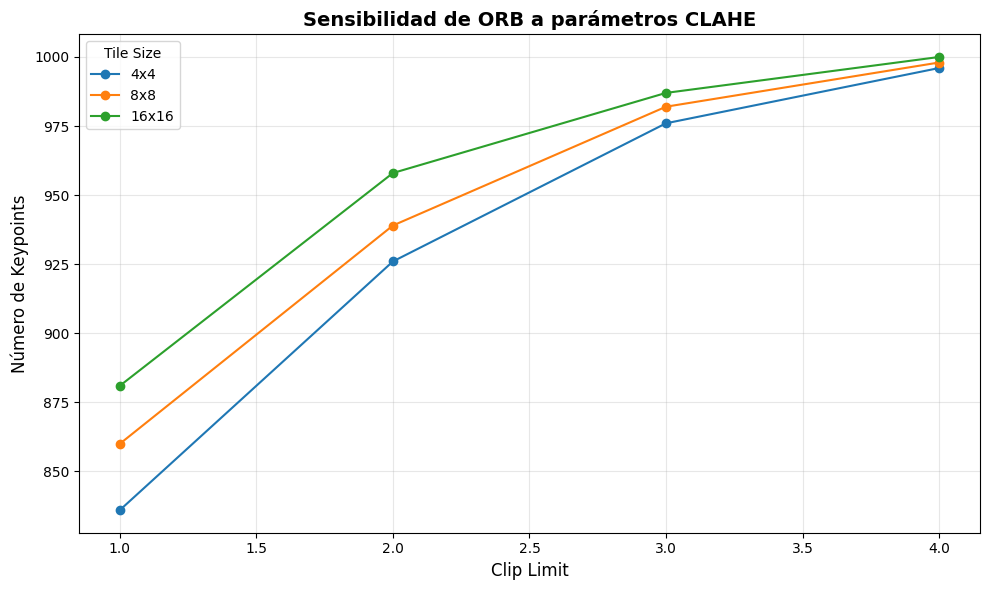

In [9]:
# Barrido de parámetros CLAHE
clip_limits = [1.0, 2.0, 3.0, 4.0]
tile_sizes = [(4, 4), (8, 8), (16, 16)]

results = []
for clip in clip_limits:
    for tile in tile_sizes:
        clahe_test = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
        L_test = clahe_test.apply(L)
        lab_test = cv2.merge([L_test, A, B])
        # El canal L ya es la luminancia, así que lo usamos directamente
        gray_test = L_test
        
        kp_test, des_test = orb.detectAndCompute(gray_test, None)
        n_kp = len(kp_test) if kp_test else 0
        
        results.append({
            'clip_limit': clip,
            'tile_size': f"{tile[0]}x{tile[1]}",
            'keypoints': n_kp
        })

df_results = pd.DataFrame(results)
print("Sensibilidad de ORB a parámetros CLAHE:")
print(df_results.pivot(index='clip_limit', columns='tile_size', values='keypoints'))

# Visualización de sensibilidad
fig, ax = plt.subplots(figsize=(10, 6))
for tile in df_results['tile_size'].unique():
    subset = df_results[df_results['tile_size'] == tile]
    ax.plot(subset['clip_limit'], subset['keypoints'], marker='o', label=tile)

ax.set_xlabel('Clip Limit', fontsize=12)
ax.set_ylabel('Número de Keypoints', fontsize=12)
ax.set_title('Sensibilidad de ORB a parámetros CLAHE', fontsize=14, fontweight='bold')
ax.legend(title='Tile Size')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../assets/ut5b_sensibilidad_ruido_moon.png', dpi=150, bbox_inches='tight')
plt.show()


ORB - Keypoints: 939, Tiempo: 6.21 ms
SIFT - Keypoints: 302, Tiempo: 23.36 ms


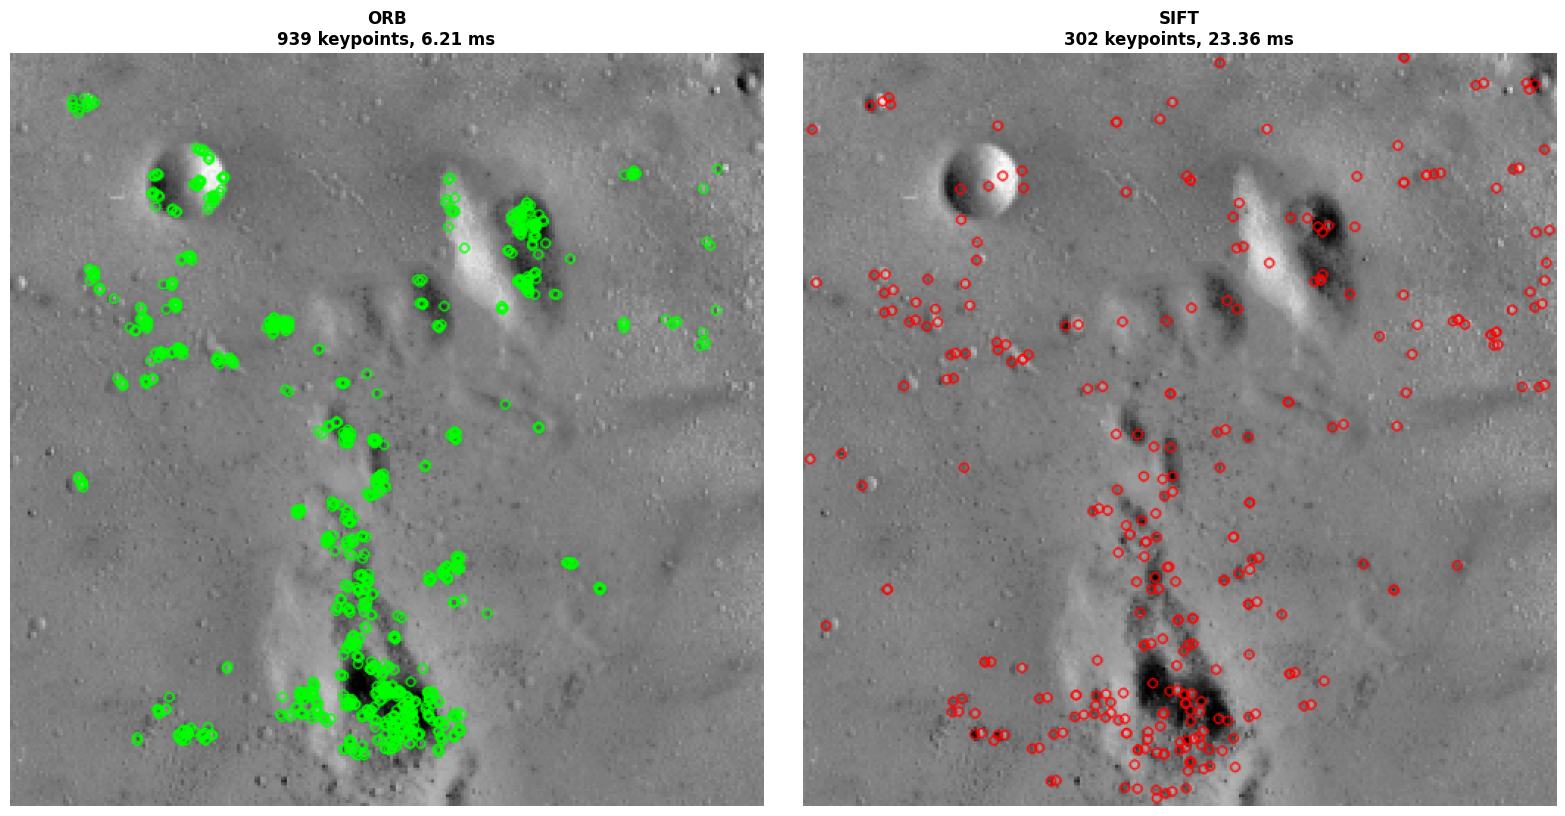

In [10]:
# Benchmark ORB vs SIFT
import time

# ORB
start = time.time()
orb_detector = cv2.ORB_create(nfeatures=1000)
kp_orb, des_orb = orb_detector.detectAndCompute(img_gray_clahe, None)
time_orb = time.time() - start

# SIFT
start = time.time()
sift = cv2.SIFT_create(nfeatures=1000)
kp_sift, des_sift = sift.detectAndCompute(img_gray_clahe, None)
time_sift = time.time() - start

print(f"ORB - Keypoints: {len(kp_orb)}, Tiempo: {time_orb*1000:.2f} ms")
print(f"SIFT - Keypoints: {len(kp_sift)}, Tiempo: {time_sift*1000:.2f} ms")

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

img_orb_viz = cv2.drawKeypoints(img_gray_clahe, kp_orb, None, color=(0, 255, 0), flags=0)
img_sift_viz = cv2.drawKeypoints(img_gray_clahe, kp_sift, None, color=(255, 0, 0), flags=0)

axes[0].imshow(img_orb_viz, cmap='gray')
axes[0].set_title(f"ORB\n{len(kp_orb)} keypoints, {time_orb*1000:.2f} ms", 
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_sift_viz, cmap='gray')
axes[1].set_title(f"SIFT\n{len(kp_sift)} keypoints, {time_sift*1000:.2f} ms", 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../assets/ut5b_benchmark_orb_sift_moon.png', dpi=150, bbox_inches='tight')
plt.show()


## 6) Dashboard de Control de Calidad (QA)

Generamos métricas de calidad para múltiples imágenes del dataset alternativo.


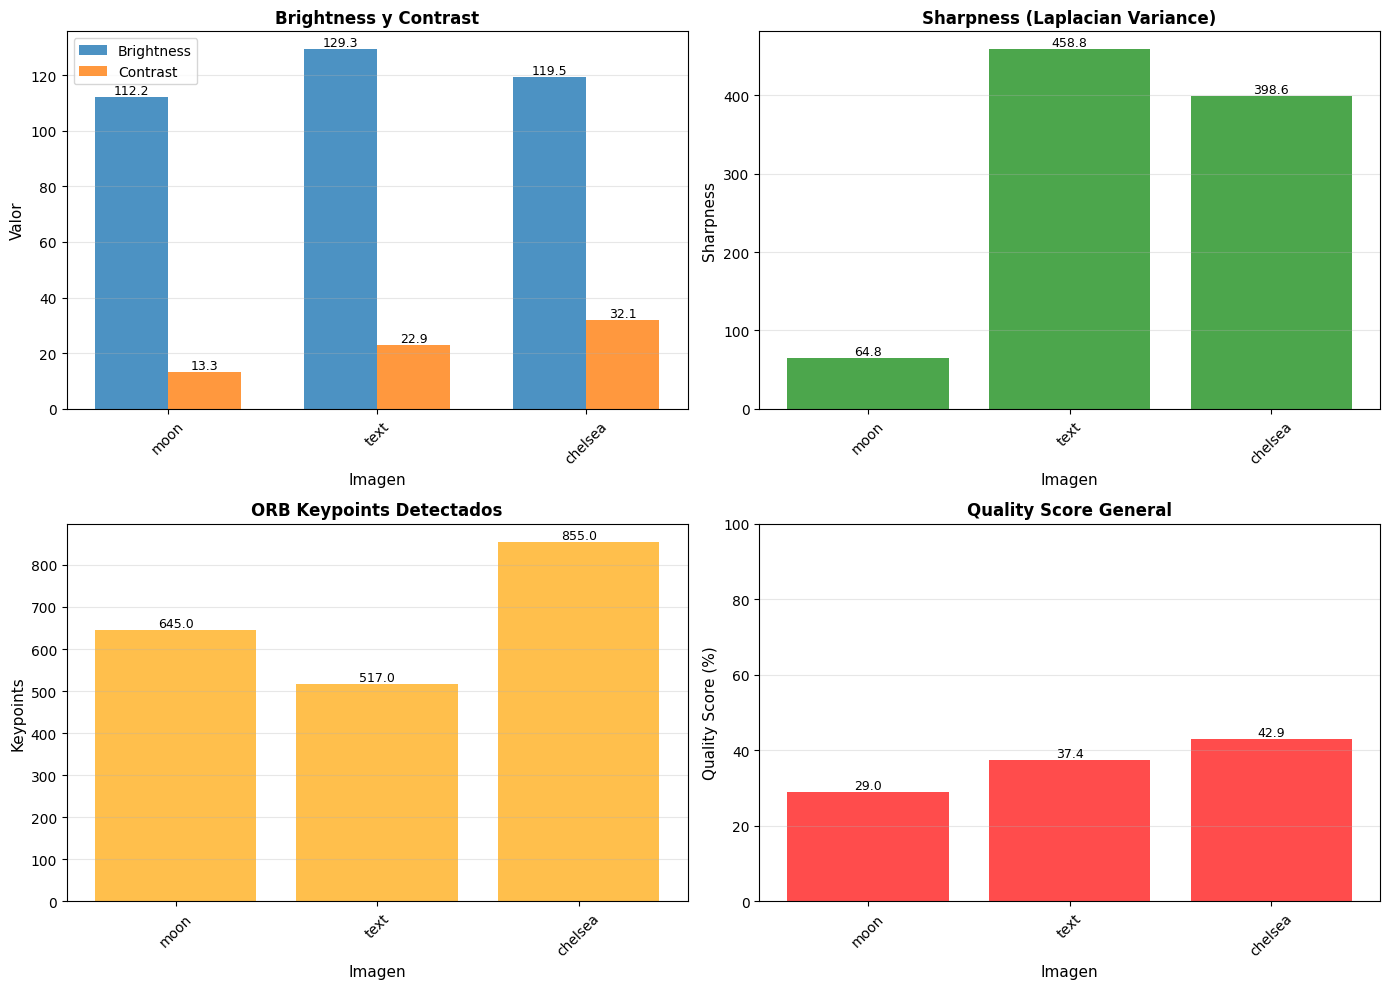


Resumen de Métricas QA:
     imagen  brightness  contrast  sharpness  keypoints  quality_score
   moon.png  112.169571 13.330291  64.783722        645      28.960364
   text.png  129.262004 22.916515 458.824831        517      37.419852
chelsea.png  119.482690 32.121932 398.607683        855      42.907992


In [12]:
# Procesar múltiples imágenes del dataset
qa_metrics = []

for img_name in ["moon.png", "text.png", "chelsea.png"]:
    img_path = RAW_DIR / img_name
    if not img_path.exists():
        continue
        
    img_bgr = cv2.imread(str(img_path))
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Métricas básicas
    brightness = img_gray.mean()
    contrast = img_gray.std()
    sharpness = cv2.Laplacian(img_gray, cv2.CV_64F).var()
    
    # Keypoints ORB
    kp, des = orb.detectAndCompute(img_gray, None)
    n_keypoints = len(kp) if kp else 0
    
    # Clasificación de calidad
    quality_score = (brightness/255 * 0.3 + contrast/255 * 0.3 + 
                     min(sharpness/1000, 1.0) * 0.2 + min(n_keypoints/1000, 1.0) * 0.2)
    
    qa_metrics.append({
        'imagen': img_name,
        'brightness': brightness,
        'contrast': contrast,
        'sharpness': sharpness,
        'keypoints': n_keypoints,
        'quality_score': quality_score * 100
    })

df_qa = pd.DataFrame(qa_metrics)

# Visualización dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Métricas por imagen
x_pos = np.arange(len(df_qa))
width = 0.35

axes[0, 0].bar(x_pos - width/2, df_qa['brightness'], width, label='Brightness', alpha=0.8)
axes[0, 0].bar(x_pos + width/2, df_qa['contrast'], width, label='Contrast', alpha=0.8)
axes[0, 0].set_xlabel('Imagen', fontsize=11)
axes[0, 0].set_ylabel('Valor', fontsize=11)
axes[0, 0].set_title('Brightness y Contrast', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels([name.replace('.png', '') for name in df_qa['imagen']], rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].bar(x_pos, df_qa['sharpness'], alpha=0.7, color='green')
axes[0, 1].set_xlabel('Imagen', fontsize=11)
axes[0, 1].set_ylabel('Sharpness', fontsize=11)
axes[0, 1].set_title('Sharpness (Laplacian Variance)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels([name.replace('.png', '') for name in df_qa['imagen']], rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

axes[1, 0].bar(x_pos, df_qa['keypoints'], alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Imagen', fontsize=11)
axes[1, 0].set_ylabel('Keypoints', fontsize=11)
axes[1, 0].set_title('ORB Keypoints Detectados', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([name.replace('.png', '') for name in df_qa['imagen']], rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].bar(x_pos, df_qa['quality_score'], alpha=0.7, color='red')
axes[1, 1].set_xlabel('Imagen', fontsize=11)
axes[1, 1].set_ylabel('Quality Score (%)', fontsize=11)
axes[1, 1].set_title('Quality Score General', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels([name.replace('.png', '') for name in df_qa['imagen']], rotation=45)
axes[1, 1].set_ylim([0, 100])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for ax in axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.tight_layout()
plt.savefig('../assets/ut5b_dashboard_qa_moon.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResumen de Métricas QA:")
print(df_qa.to_string(index=False))
